# Problem: Write a Custom Activation Function with Autograd

### Problem Statement
Implement a **custom activation function**, **Learned-SiLU**, using `torch.autograd.Function`. The activation function should be based on the SiLU formula \( x \cdot \text{sigmoid}(x) \) but include a **learnable slope parameter**. Use this custom activation function in a simple linear regression model.

### Requirements
1. **Define the Custom Activation Function**:
   - Implement a custom activation function, **Learned-SiLU**, where the output is calculated as:
     $$
     \text{Learned-SiLU}(x) = \text{slope} \cdot x \cdot \text{sigmoid}(x)
     $$
   - The **slope** should be a learnable parameter.

2. **Autograd Implementation**:
   - Use `torch.autograd.Function` to define the forward and backward passes for the custom activation function.

3. **Integrate the Activation Function**:
   - Incorporate the custom activation function into a simple linear regression model.
   - Train the model to verify the functionality of the activation function.

### Constraints
- Ensure the **slope parameter** is properly initialized and updated during training.

<details>
  <summary>💡 Hint</summary>
  Some details: https://pytorch.org/tutorials/beginner/examples_autograd/two_layer_net_custom_function.html
</details>


<details>
  <summary>💡 Alternate Implementation?</summary>
  Can be done with nn.Module without implementing backward.
</details>

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

In [30]:
# Generate synthetic data
torch.manual_seed(42)
X = torch.rand(100, 1) * 10  # 100 data points between 0 and 10
y = 2 * X + 3 + torch.randn(100, 1)  # Linear relationship with noise

In [31]:
class LearnedSiLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, slope):
        # Save the input tensor and slope for backward computation
        sigmoid_x = torch.sigmoid(x)
        ctx.save_for_backward(x, slope, sigmoid_x)
        return slope * x * sigmoid_x

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve the input and slope saved in the forward pass
        x, slope, sigmoid_x = ctx.saved_tensors
        grad_x = grad_output * slope * (sigmoid_x + x * sigmoid_x * (1 - sigmoid_x))
        grad_slope = (grad_output * x * sigmoid_x).sum().view(1)
        # print(grad_x)
        # print(grad_slope)
        return grad_x, grad_slope


# Define the Linear Regression Model
class LinearRegressionModel(nn.Module):
    def __init__(self, slope=1):
        super().__init__()
        self.slope = nn.Parameter(torch.ones(1) * slope)

    def forward(self, x):
        # Use the custom LearnedSiLUFunction
        return LearnedSiLUFunction.apply(x, self.slope)

# Initialize the model, loss function, and optimizer
model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    predictions = model(X)
    loss = criterion(predictions, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Log progress every 100 epochs
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/1000], Loss: 75.8140
Epoch [2/1000], Loss: 10.7472
Epoch [3/1000], Loss: 4.7672
Epoch [4/1000], Loss: 4.2176
Epoch [5/1000], Loss: 4.1671
Epoch [6/1000], Loss: 4.1624
Epoch [7/1000], Loss: 4.1620
Epoch [8/1000], Loss: 4.1619
Epoch [9/1000], Loss: 4.1619
Epoch [10/1000], Loss: 4.1619
Epoch [11/1000], Loss: 4.1619
Epoch [12/1000], Loss: 4.1619
Epoch [13/1000], Loss: 4.1619
Epoch [14/1000], Loss: 4.1619
Epoch [15/1000], Loss: 4.1619
Epoch [16/1000], Loss: 4.1619
Epoch [17/1000], Loss: 4.1619
Epoch [18/1000], Loss: 4.1619
Epoch [19/1000], Loss: 4.1619
Epoch [20/1000], Loss: 4.1619
Epoch [21/1000], Loss: 4.1619
Epoch [22/1000], Loss: 4.1619
Epoch [23/1000], Loss: 4.1619
Epoch [24/1000], Loss: 4.1619
Epoch [25/1000], Loss: 4.1619
Epoch [26/1000], Loss: 4.1619
Epoch [27/1000], Loss: 4.1619
Epoch [28/1000], Loss: 4.1619
Epoch [29/1000], Loss: 4.1619
Epoch [30/1000], Loss: 4.1619
Epoch [31/1000], Loss: 4.1619
Epoch [32/1000], Loss: 4.1619
Epoch [33/1000], Loss: 4.1619
Epoch [34/1000], 

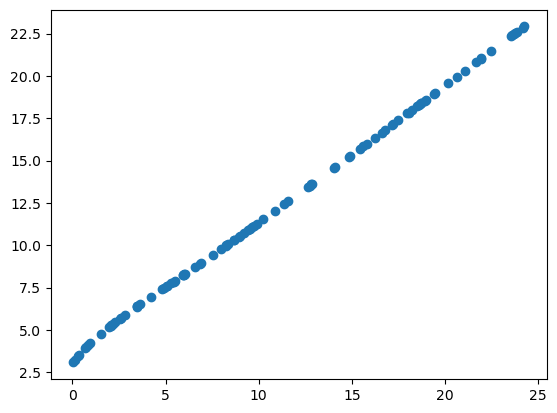

In [32]:
torch.manual_seed(39)
X = torch.rand(100, 1) * 10  # 100 data points between 0 and 10
y = 2 * X + 3

predictions = model(X)

import matplotlib.pyplot as plt

plt.scatter(predictions.detach().numpy(), y.numpy())

In [ ]:
class LearnedSiLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, slope):
        sigmoid_x = torch.sigmoid(x)
        ctx.save_for_backward(x, slope, sigmoid_x)
        return slope * x * sigmoid_x

    @staticmethod
    def backward(ctx, grad_y):
        x, slope, sigmoid_x = ctx.saved_tensors
        grad_x = grad_y * slope * (sigmoid_x + x * sigmoid_x * (1 - sigmoid_x))
        grad_slope = (grad_y * x * sigmoid_x).sum().view(1)
        return grad_x, grad_slope